In [1]:
!pip install yfinance
import yfinance as yf

data = yf.download('AAPL', period='5y')
data.to_csv('AAPL.csv')
data.head()

/tmp/ipykernel_1806/3268461083.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', period='5y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2021-07-12,140.851654,142.625710,140.364278,142.518486,76299700
2021-07-13,141.962845,143.736900,140.003599,140.393494,100827100
2021-07-14,145.384247,145.793656,143.951360,144.360769,127050800
2021-07-15,144.731201,146.212829,143.376296,145.472022,106820300
2021-07-16,142.693939,145.978849,142.196821,144.711683,93251400


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv('AAPL.csv', skiprows=[1, 2], header=0)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

df.head()

,Date,Close,High,Low,Open,Volume
0,2021-07-12,140.85,142.63,140.36,142.52,76299700
1,2021-07-13,141.96,143.74,140.00,140.39,100827100
2,2021-07-14,145.38,145.79,143.95,144.36,127050800
3,2021-07-15,144.73,146.21,143.38,145.47,106820300
4,2021-07-16,142.69,145.98,142.20,144.71,93251400


In [4]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
df.info()

Dataset shape: 1255 rows, 6 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1255 non-null   object 
 1   Close   1255 non-null   float64
 2   High    1255 non-null   float64
 3   Low     1255 non-null   float64
 4   Open    1255 non-null   float64
 5   Volume  1255 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 59.0+ KB


In [5]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total trading days: {len(df)}")

Date range: 2021-07-12 to 2026-07-10
Total trading days: 1255


In [6]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,1255,"1,255.00","1,255.00","1,255.00","1,255.00","1,255.00"
mean,2024-01-07 11:20:24.860557824,194.63,196.58,192.52,194.44,"65,099,408.37"
min,2021-07-12 00:00:00,122.93,125.64,122.10,123.91,"17,910,600.00"
25%,2022-10-06 12:00:00,157.09,159.58,155.35,157.05,"45,731,700.00"
50%,2024-01-08 00:00:00,183.44,184.86,181.56,183.31,"56,934,900.00"
75%,2025-04-08 12:00:00,226.87,229.18,225.17,227.04,"77,101,050.00"
max,2026-07-10 00:00:00,316.22,317.40,312.17,315.29,"318,679,900.00"
std,NaN,45.42,45.79,45.03,45.39,"28,677,201.73"


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate dates: {df['Date'].duplicated().sum()}")

Missing values per column:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Duplicate dates: 0


In [8]:
df = df.sort_values('Date').reset_index(drop=True)

print("Any non-positive prices?", (df[['Open','High','Low','Close']] <= 0).any().any())
print("Any non-positive volume?", (df['Volume'] <= 0).any())

inconsistent = df[(df['High'] < df['Low']) | (df['High'] < df['Open']) | (df['High'] < df['Close'])]
print(f"Rows with logical inconsistencies (High < other prices): {len(inconsistent)}")

Any non-positive prices? False
Any non-positive volume? False
Rows with logical inconsistencies (High < other prices): 0


In [9]:
df.set_index('Date', inplace=True)
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2021-07-12,140.85,142.63,140.36,142.52,76299700
2021-07-13,141.96,143.74,140.00,140.39,100827100
2021-07-14,145.38,145.79,143.95,144.36,127050800
2021-07-15,144.73,146.21,143.38,145.47,106820300
2021-07-16,142.69,145.98,142.20,144.71,93251400


In [10]:
df['Daily_Change'] = df['Close'] - df['Open']
df['Daily_Pct_Change'] = df['Close'].pct_change() * 100
df['Daily_Range'] = df['High'] - df['Low']

df[['Open','Close','Daily_Change','Daily_Pct_Change','Daily_Range']].head()

,Open,Close,Daily_Change,Daily_Pct_Change,Daily_Range
Date,,,,,
2021-07-12,142.52,140.85,-1.67,NaN,2.26
2021-07-13,140.39,141.96,1.57,0.79,3.73
2021-07-14,144.36,145.38,1.02,2.41,1.84
2021-07-15,145.47,144.73,-0.74,-0.45,2.84
2021-07-16,144.71,142.69,-2.02,-1.41,3.78


In [11]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['YearMonth'] = df.index.to_period('M')

yearly_summary = df.groupby('Year').agg(
    Avg_Close=('Close', 'mean'),
    Total_Volume=('Volume', 'sum'),
    Avg_Daily_Range=('Daily_Range', 'mean')
).round(2)

yearly_summary

,Avg_Close,Total_Volume,Avg_Daily_Range
Year,,,
2021,149.55,10329389800,2.89
2022,151.81,22065504500,4.13
2023,170.19,14805886900,2.84
2024,205.46,14390908500,3.66
2025,231.35,13543944600,5.09
2026,275.03,6564123200,6.15


In [12]:
monthly_summary = df.groupby('YearMonth').agg(
    Avg_Close=('Close', 'mean'),
    Total_Volume=('Volume', 'sum')
).round(2)

monthly_summary.tail(12)

,Avg_Close,Total_Volume
YearMonth,,
2025-08,223.94,1218079100
2025-09,241.80,1265536400
2025-10,257.57,1097142200
2025-11,271.08,877578200
2025-12,275.79,924528800
2026-01,257.17,1040017300
2026-02,268.86,988921000
2026-03,254.67,900035700
2026-04,264.45,907538500


In [13]:
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

df[['Close','MA_7','MA_30']].tail(10)

,Close,MA_7,MA_30
Date,,,
2026-06-26,283.78,291.04,300.29
2026-06-29,281.74,289.01,299.74
2026-06-30,289.36,287.77,299.38
2026-07-01,294.38,287.40,299.27
2026-07-02,308.63,289.45,299.59
2026-07-06,312.66,292.24,299.93
2026-07-07,310.66,297.32,300.12
2026-07-08,313.39,301.55,300.28
2026-07-09,316.22,306.47,300.54


In [14]:
start_price = df['Close'].iloc[0]
end_price = df['Close'].iloc[-1]
total_return_pct = ((end_price - start_price) / start_price) * 100

print(f"Starting price ({df.index[0].date()}): ${start_price:.2f}")
print(f"Ending price ({df.index[-1].date()}): ${end_price:.2f}")
print(f"Total return over 5 years: {total_return_pct:.2f}%")

Starting price (2021-07-12): $140.85
Ending price (2026-07-10): $315.32
Total return over 5 years: 123.87%


In [15]:
monthly_close = df['Close'].resample('ME').last()
monthly_returns = monthly_close.pct_change() * 100

monthly_returns.tail(12).round(2)

,Close
Date,
2025-08-31,11.96
2025-09-30,9.69
2025-10-31,6.18
2025-11-30,3.24
2025-12-31,-2.51
2026-01-31,-4.55
2026-02-28,1.91
2026-03-31,-3.93
2026-04-30,6.92


In [16]:
df['Volatility_30'] = df['Daily_Pct_Change'].rolling(window=30).std()

df[['Close','Daily_Pct_Change','Volatility_30']].tail(10)

,Close,Daily_Pct_Change,Volatility_30
Date,,,
2026-06-26,283.78,3.14,1.82
2026-06-29,281.74,-0.72,1.83
2026-06-30,289.36,2.70,1.90
2026-07-01,294.38,1.73,1.92
2026-07-02,308.63,4.84,2.12
2026-07-06,312.66,1.31,2.12
2026-07-07,310.66,-0.64,2.12
2026-07-08,313.39,0.88,2.11
2026-07-09,316.22,0.90,2.12


In [17]:
df['Cumulative_Return'] = (1 + df['Daily_Pct_Change']/100).cumprod()

print(f"$1 invested on {df.index[0].date()} would be worth ${df['Cumulative_Return'].iloc[-1]:.2f} by {df.index[-1].date()}")

$1 invested on 2021-07-12 would be worth $2.24 by 2026-07-10


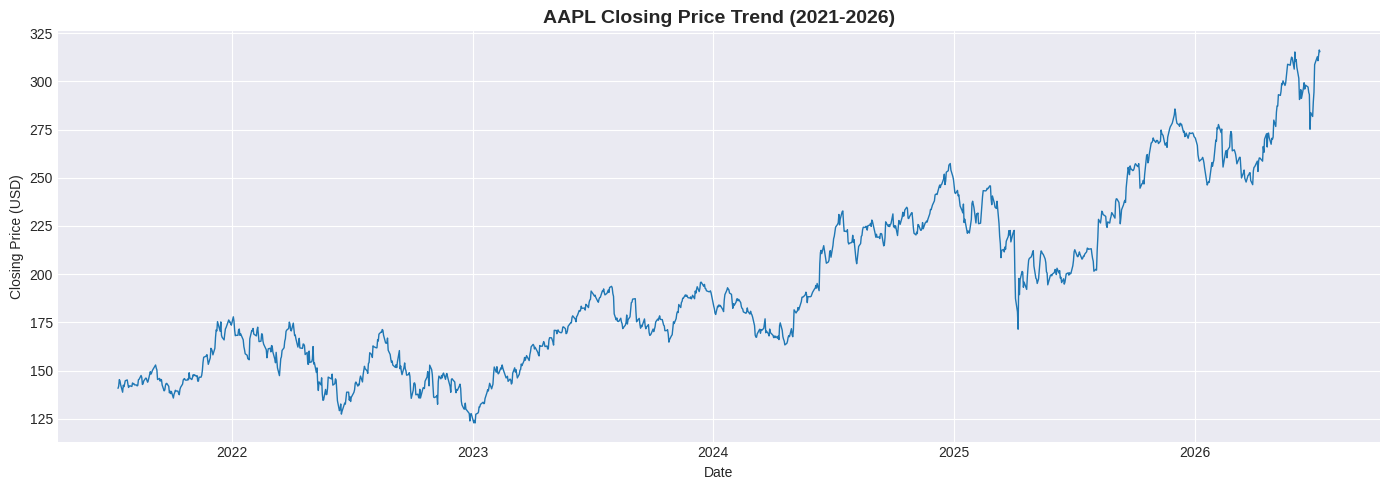

In [18]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], color='#1f77b4', linewidth=1)
plt.title('AAPL Closing Price Trend (2021-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.tight_layout()
plt.show()

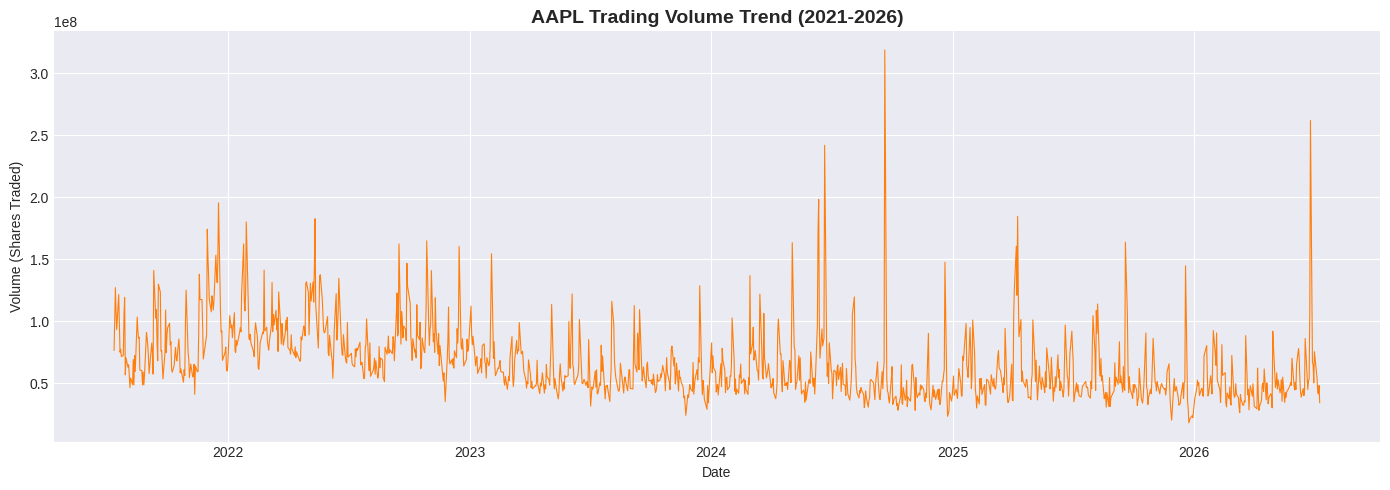

In [19]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Volume'], color='#ff7f0e', linewidth=0.8)
plt.title('AAPL Trading Volume Trend (2021-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volume (Shares Traded)')
plt.tight_layout()
plt.show()

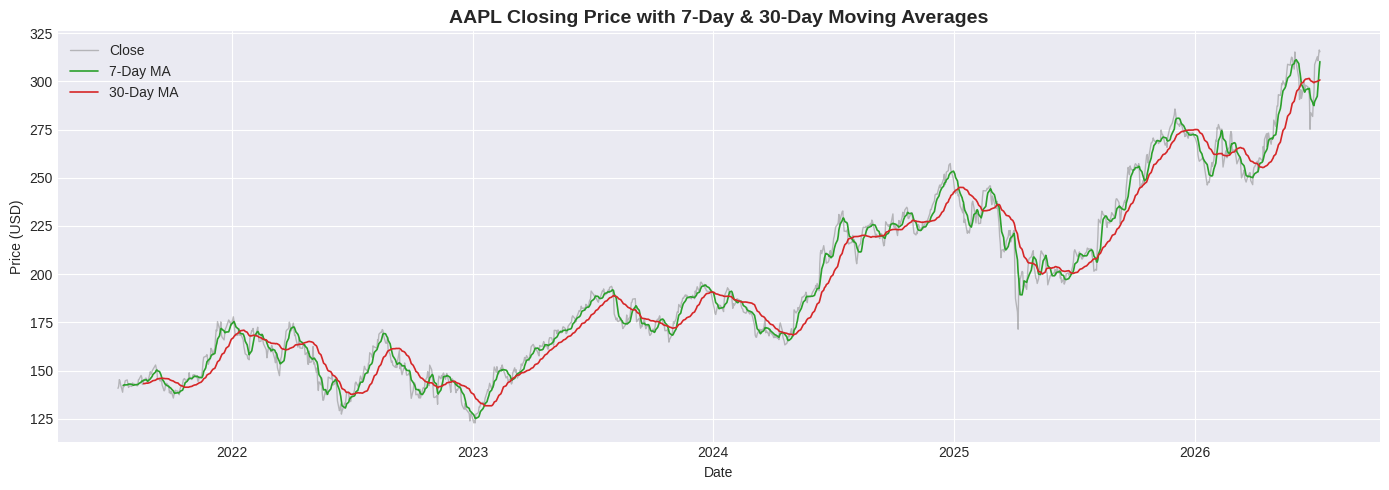

In [20]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Close'], label='Close', color='gray', alpha=0.5, linewidth=1)
plt.plot(df.index, df['MA_7'], label='7-Day MA', color='#2ca02c', linewidth=1.2)
plt.plot(df.index, df['MA_30'], label='30-Day MA', color='#d62728', linewidth=1.2)
plt.title('AAPL Closing Price with 7-Day & 30-Day Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

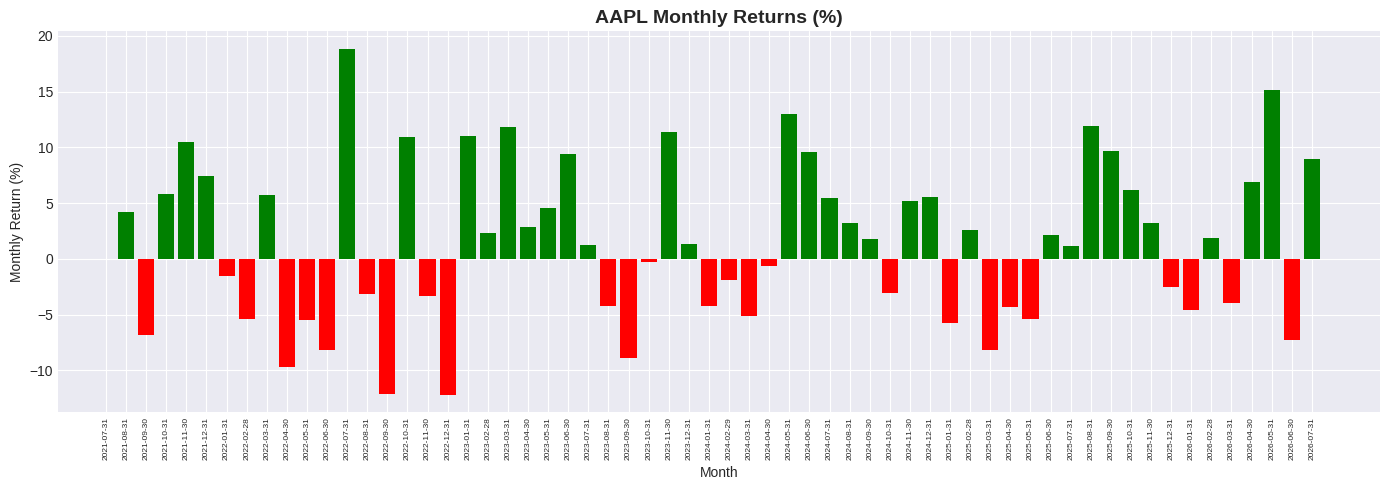

In [21]:
plt.figure(figsize=(14,5))
colors = ['green' if x >= 0 else 'red' for x in monthly_returns.fillna(0)]
plt.bar(monthly_returns.index.astype(str), monthly_returns.values, color=colors)
plt.title('AAPL Monthly Returns (%)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Monthly Return (%)')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

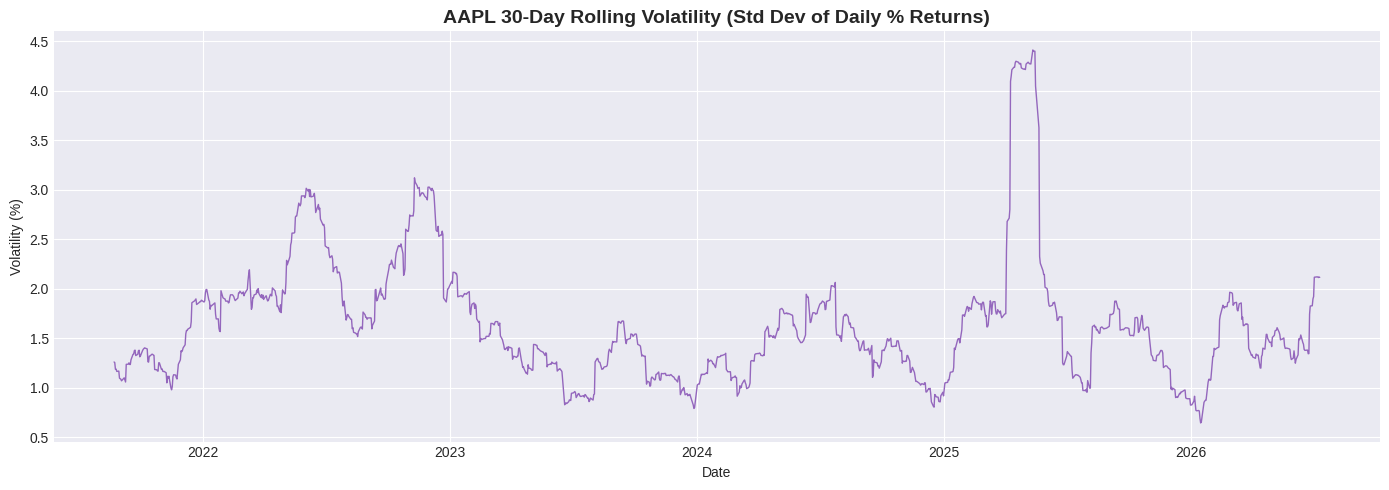

In [22]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['Volatility_30'], color='#9467bd', linewidth=1)
plt.title('AAPL 30-Day Rolling Volatility (Std Dev of Daily % Returns)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Volatility (%)')
plt.tight_layout()
plt.show()

## Key Findings & Conclusions

**Overall Trend:** AAPL grew substantially over the 5-year period (July 2021 - July 2026),
with the closing price rising from roughly \$140 to over \$315, delivering a total return of
approximately 124%.

**Moving Averages:** The 30-day moving average confirms a long-term uptrend, while the
7-day average reveals more frequent short-term swings.

**Volatility:** 30-day rolling volatility shows periods of market stress interspersed
with calmer trading. Notably, volatility stayed unusually high for an extended stretch
around mid-2025, rather than spiking and quickly reverting — suggesting a sustained
period of market uncertainty rather than a single shock event.

**Monthly Returns:** Returns are mixed month-to-month — nearly 45% of months were negative —
reflecting sensitivity to earnings, product launches, and market sentiment, even as the
long-term trend stayed positive.

**Volume:** Volume shows occasional sharp spikes (e.g., ~318M shares in one session), typically
tied to earnings releases or major news.

**Recommendation:** Long-term investors were rewarded for holding through short-term dips.
Monitoring 7-day/30-day moving average crossovers can help time entries; high-volatility
periods warrant closer risk management.